# Individual payoffs and joint efficiency in repeated games

GPT-6 Luna (OpenAI Decisions) and Jev 1.13.0 (TypeSafe), 6 October 2026.
Revised 7 October. This analysis uses **direct API-selected actions only**:
48 head-to-head matches, followed by a separate check of 12 self-play matches.
Each match has twenty rounds. There is no added action randomization.

Jev earns the higher head-to-head mean in all three games. Neither player
participates in a joint-optimal head-to-head round, and none of the 48 matches
attains a Pareto-efficient cumulative vector. Individual advantage and joint
payoff attainment are evaluated separately.

All results below use the saved observations. The complete original archive is
replayed for integrity, but extra randomized matches and diagnostic probes are
excluded from this analysis. Execution makes no API requests. The full repository
or replication bundle is required, not just this notebook file.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
from IPython.display import display, HTML, Image
root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'lludens/sysone').exists())
experiment = root/'experiments/decisions_jev_games_2026_10_06'
sys.path.insert(0, str(root)); sys.path.insert(0, str(experiment))
from analyze import audit_and_load
from direct_results import summarize_direct, TITLES, NAMES, stage_payoffs, pareto_frontier
rounds, matches, replay, journal = audit_and_load()
summary = summarize_direct(replay)
assert summary['matches'] == 60 and summary['decisions'] == 2400
assert len([m for m in summary['match_results'] if m['kind']=='h2h']) == 48

## Recorded opening calls

Both models' actual opening PD prompts, LLM invocations, and typed responses
appear below. Luna is in seat 1 and Jev in seat 2; both select Defect. Returned
probabilities do not randomize their actions. Request JSON is reconstructed
through the pinned plugins from the exact saved arguments, not captured HTTP
traffic. The response payload is the retained `response.text()` answer.

In [2]:
from opening_examples import opening_examples, examples_html
examples = opening_examples(journal)
display(HTML('<details><summary>Shared instructions</summary><pre>' +
             examples[0]['llm_kwargs']['system'] + '</pre></details>' + examples_html(examples)))

## Design and information set

Each player maximizes its own expected total match points, including future
rounds—not its lead over the opponent or joint welfare. The same two players
interact for exactly twenty simultaneous rounds, with the rules and final round
known to both. No discounting, communication, side payments or later-match
rewards are present. The opponent's identity and strategy are not disclosed.

**Before every round t**, both services receive a fresh request containing the
rules, legal actions, player number, current round and horizon; every completed
round's actions and both payoffs (from that player's perspective); and own
cumulative points. The opponent's cumulative points are inferable from the
history. Neither current-round action is revealed until both are chosen.
History is supplied explicitly, without persistent chat or cross-match memory.
Every match therefore has **40 fresh decisions, 20 per player**.

The head-to-head design is 3 games × 8 seed pairs × 2 seat swaps: 48 matches,
960 rounds and 1,920 decisions. Options are shuffled by seat and round, with
seat-specific schedules held fixed across swaps. Seeds do not guarantee backend
determinism. Twelve self-play matches (two per model per game) add 240 rounds and
480 decisions. Rounds within a match are not independent replications.

## Games and cumulative payoff benchmarks

Let U_i be the sum of player i's twenty round payoffs and J = U_1 + U_2.
All scores are in each game's points; no scores are pooled across games.

**Prisoner's Dilemma.** CC=(3,3), CD=(0,5), DC=(5,0), DD=(1,1).
Defection is a strictly dominant stage-game action. All-DD gives (20,20).
All-CC gives (60,60) and maximum joint payoff J*=120.

**Stag Hunt.** SS=(4,4), SH=(0,3), HS=(3,0), HH=(3,3).
SS and HH are pure stage equilibria. Hare guarantees 3; Stag is strictly preferred
only at a belief greater than 3/4 on the opponent choosing Stag. All-HH gives
(60,60); all-SS gives (80,80), the unique efficient cumulative vector, with J*=160.

**Two-player public goods.** Each player receives a fresh endowment of 10 tokens.
Contributions c_i are in {0,2,4,6,8,10}; the pool is multiplied by 1.6 and split
equally. Own payoff is 10-c_i+0.8(c_i+c_j); joint payoff is 20+0.6(c_i+c_j).
Unused tokens do not carry forward but points accumulate. Zero contribution is
strictly dominant in a stage. Contributions (0,0), (10,10), (0,10) give payoffs
(10,10), (16,16), (18,8). Full contribution throughout gives (320,320), J*=640;
zero contribution throughout gives (200,200).

The symmetric joint-maximizing vectors are **jointly feasible Pareto-efficient
benchmarks**, not independent individual score ceilings. A vector is Pareto-efficient
if no feasible change improves one player's payoff without worsening the other's.
Other asymmetric frontier points exist in PD and public goods: perpetual (D,C)
gives (100,0); contributions (0,10) throughout give (360,160).

We distinguish (i) mean joint payoff share J/J*, (ii) the count of full matches
attaining J*, and (iii) the count on the full Pareto frontier. The share is not an
attainment probability. Exact rational arithmetic constructs the feasible
cumulative frontier; maximizing the sum alone does not define its other points.

In [3]:
display(pd.DataFrame([
    {'game':TITLES[g], 'actions_each_round':' / '.join(b['actions']),
     'U1_star':b['individual'][0], 'U2_star':b['individual'][1], 'J_star':b['joint']}
    for g,b in summary['benchmarks'].items()
]))

,game,actions_each_round,U1_star,U2_star,J_star
0,Prisoner’s Dilemma,C / C,60.0,60.0,120.0
1,Stag Hunt,Stag / Stag,80.0,80.0,160.0
2,Two-player public goods,10 / 10,320.0,320.0,640.0


## Head-to-head outcomes

All payoffs are **per complete twenty-round match**, averaged across sixteen
matches per game. Match counts, not independent-round sample sizes, characterize
the design. The joint maximum requires the efficient cooperative pair in all
20 rounds. All observed head-to-head vectors are strictly dominated by their
symmetric benchmark for both players.

,game,matches,seat_pairs,mean_luna_payoff,mean_jev_payoff,mean_joint_payoff,joint_maximum,mean_joint_share,mean_joint_shortfall,joint_maximum_matches,pareto_efficient_matches
0,prisoners_dilemma,16,8,19.2500,23.9375,43.1875,120.0,0.3599,76.8125,0,0
1,stag_hunt,16,8,57.5625,60.0000,117.5625,160.0,0.7348,42.4375,0,0
2,public_goods,16,8,199.5750,201.7000,401.2750,640.0,0.6270,238.7250,0,0


,game,luna_wins,ties,jev_wins,joint_optimal_rounds,rounds_observed,action_profiles
0,prisoners_dilemma,1,2,13,0,320,"{'C / D': 16, 'D / C': 1, 'D / D': 303}"
1,stag_hunt,0,3,13,0,320,"{'Hare / Hare': 307, 'Stag / Hare': 13}"
2,public_goods,0,5,11,0,320,"{'0 / 0': 303, '2 / 0': 17}"


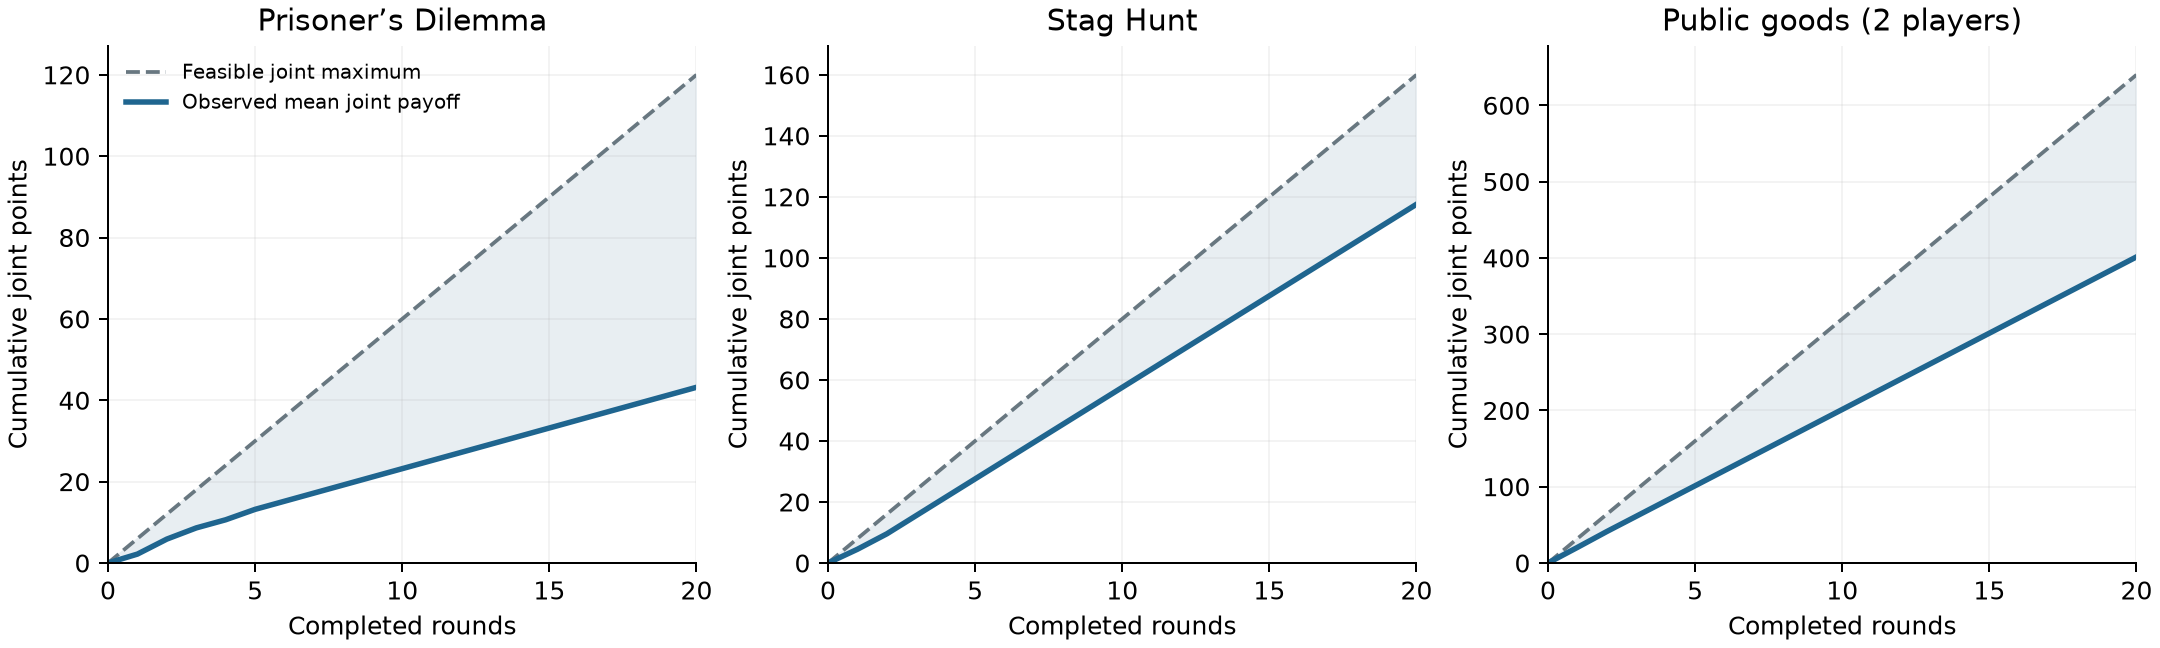

In [4]:
head = pd.DataFrame(summary['h2h'])
display(head[['game','matches','seat_pairs','mean_luna_payoff','mean_jev_payoff',
              'mean_joint_payoff','joint_maximum','mean_joint_share','mean_joint_shortfall',
              'joint_maximum_matches','pareto_efficient_matches']].round(4))
display(head[['game','luna_wins','ties','jev_wins','joint_optimal_rounds','rounds_observed',
              'action_profiles']])
display(Image(filename=str(experiment/'report/payoffs.png')))

PD mutual defection occurs in 303/320 rounds. Luna cooperates unilaterally in
16 rounds, Jev in one; there is no mutual cooperation. In Stag Hunt, Jev always
chooses Hare; Luna chooses unmatched Stag 13 times. The remaining 307 rounds are
Hare/Hare, so even the all-Hare joint benchmark is not reached on average.

In public goods, Jev always contributes zero; Luna contributes two tokens in 17
rounds and zero in the rest. These contributions raise joint payoff slightly
above the all-zero baseline but lower Luna's payoff while increasing Jev's.
Jev's mean individual advantage is 4.6875, 2.4375 and 2.125 points per match in PD,
Stag Hunt and public goods. The corresponding joint payoff shares are about
36.0%, 73.5% and 62.7%. No head-to-head match is on the Pareto frontier.

In [5]:
individual = pd.DataFrame(summary['match_results'])
display(individual[individual.kind=='h2h'][
    ['id','players','luna_payoff','jev_payoff','joint_payoff','joint_share',
     'joint_maximum_attained','pareto_efficient']].round(4))

,id,players,luna_payoff,jev_payoff,joint_payoff,joint_share,joint_maximum_attained,pareto_efficient
0,prisoners_dilemma-argmax-00-swap0,"[decisions, jev]",19.0,24.0,43.0,0.3583,False,False
1,prisoners_dilemma-argmax-00-swap1,"[jev, decisions]",20.0,20.0,40.0,0.3333,False,False
2,stag_hunt-argmax-00-swap0,"[decisions, jev]",57.0,60.0,117.0,0.7312,False,False
3,stag_hunt-argmax-00-swap1,"[jev, decisions]",57.0,60.0,117.0,0.7312,False,False
4,public_goods-argmax-00-swap0,"[decisions, jev]",199.2,203.2,402.4,0.6288,False,False
5,public_goods-argmax-00-swap1,"[jev, decisions]",199.2,203.2,402.4,0.6288,False,False
6,prisoners_dilemma-argmax-01-swap0,"[decisions, jev]",20.0,20.0,40.0,0.3333,False,False
7,prisoners_dilemma-argmax-01-swap1,"[jev, decisions]",19.0,24.0,43.0,0.3583,False,False
8,stag_hunt-argmax-01-swap0,"[decisions, jev]",57.0,60.0,117.0,0.7312,False,False
9,stag_hunt-argmax-01-swap1,"[jev, decisions]",57.0,60.0,117.0,0.7312,False,False


## Self-play, reported separately

There are just two matches per model per game. U1 and U2 now denote seats of the
same model, not Luna and Jev. Do not pool these observations with the head-to-head
comparison. One Luna Stag Hunt match reaches (80,80); the other reaches (57,57).
Jev reaches (60,60) in both. No other self-play match reaches the joint maximum or
the Pareto frontier. These two runs do not establish equilibrium-selection rates.

In [6]:
self_play = pd.DataFrame(summary['self_play'])
display(self_play[['game','provider','matches','mean_seat1_payoff','mean_seat2_payoff',
                   'mean_joint_payoff','mean_joint_share','joint_maximum_matches',
                   'pareto_efficient_matches']].round(4))
display(individual[individual.kind=='self'][
    ['id','seat1_payoff','seat2_payoff','joint_payoff','joint_maximum_attained']])

,game,provider,matches,mean_seat1_payoff,mean_seat2_payoff,mean_joint_payoff,mean_joint_share,joint_maximum_matches,pareto_efficient_matches
0,prisoners_dilemma,decisions,2,21.5,21.5,43.0,0.3583,0,0
1,prisoners_dilemma,jev,2,20.0,20.0,40.0,0.3333,0,0
2,stag_hunt,decisions,2,68.5,68.5,137.0,0.8562,1,1
3,stag_hunt,jev,2,60.0,60.0,120.0,0.7500,0,0
4,public_goods,decisions,2,201.2,204.2,405.4,0.6334,0,0
5,public_goods,jev,2,200.0,200.0,400.0,0.6250,0,0


,id,seat1_payoff,seat2_payoff,joint_payoff,joint_maximum_attained
48,prisoners_dilemma-self-decisions-00,19.0,24.0,43.0,False
49,prisoners_dilemma-self-jev-00,20.0,20.0,40.0,False
50,stag_hunt-self-decisions-00,80.0,80.0,160.0,True
51,stag_hunt-self-jev-00,60.0,60.0,120.0,False
52,public_goods-self-decisions-00,202.4,208.4,410.8,False
53,public_goods-self-jev-00,200.0,200.0,400.0,False
54,prisoners_dilemma-self-decisions-01,24.0,19.0,43.0,False
55,prisoners_dilemma-self-jev-01,20.0,20.0,40.0,False
56,stag_hunt-self-decisions-01,57.0,57.0,114.0,False
57,stag_hunt-self-jev-01,60.0,60.0,120.0,False


## Interpretation and limits

Jev earns more in these head-to-head games while neither pairing attains joint
efficiency. The difference largely reflects Luna's costly unilateral cooperation
or unmatched Stag choices. It does not identify a particular strategy, belief,
learning mechanism or general difference in reasoning ability.

Welfare benchmarks are not necessarily equilibria or individually optimal
responses. For finite PD and public goods, standard backward induction under
common knowledge of rationality selects defection/zero contribution; the prompts
do not assert that the opponent satisfies those assumptions. Low cooperation
alone is not an error. Hare/Hare is an equilibrium even though SS Pareto-dominates it.

This is a descriptive pilot: one framing, one payoff specification per game,
one known horizon, no communication, and eight seat-swapped pairs per game.
No uncertainty across prompts, horizons, opponents or repeated service calls is
estimated. Two-player public goods does not establish behavior in larger groups.

## Replication provenance

The complete archive (including excluded randomized matches and probes) is
preserved. `data/summary.json` remains the original archival summary;
`data/direct_summary.json` contains this memo's outcomes. Every recorded game
prompt and history is checked by the offline replay. Twelve initially rejected
probability-validation responses, including one diagnostic, were not retained
and were reissued; no failed request became a fallback action. See the experiment
README for complete execution provenance and pinned dependencies.

The HTML memo supplies a direct-action replay with individual and joint payoff
accounting. `report/direct_matches.csv` contains all sixty match-level outcomes.
Neither this revision nor its analysis requires any new model calls.